In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

# Task 1 — A Single Neuron in NumPy

In [2]:
df = load_breast_cancer()

In [3]:
X = df.data
y = df.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)
w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01
probs = forward(X_test_scaled[:5], w, b)
print("Predicted probabilities:")
print(probs)

Predicted probabilities:
[0.49622457 0.51754028 0.50708005 0.48744002 0.48394608]


In machine-learning terms, I implemented a single artificial neuron, which is mathematically equivalent to logistic regression.

# Task 2 — A Two-Layer MLP in NumPy

In [7]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1, seed=42):
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))
    def relu(self, z):
        return np.maximum(0, z)
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    def forward(self, X):
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.relu(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        y_hat = self.sigmoid(z2)
        return y_hat

In [8]:
mlp = NumpyMLP(input_size=30, hidden_size=8, output_size=1)
predictions = mlp.forward(X_test_scaled)
print("Output shape:", predictions.shape)
print("First 5 predictions:")
print(predictions[:5])

Output shape: (114, 1)
First 5 predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


The output shape is `(N, 1)` because a binary classifier should return one probability for each input sample, even though the model is not trained yet; the architecture already defines one sigmoid output neuron per row.

# Task 3 — The Same Network in PyTorch

In [9]:
import torch
import torch.nn as nn

class TorchMLP(nn.Module):
    def __init__(self, n_inputs=30, n_hidden=8, n_outputs=1):
        super().__init__()
        self.fc1 = nn.Linear(n_inputs, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_outputs)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

torch_model = TorchMLP()

with torch.no_grad():
    torch_model.fc1.weight.data = torch.from_numpy(mlp.W1.T).float()
    torch_model.fc1.bias.data = torch.from_numpy(mlp.b1.ravel()).float()
    torch_model.fc2.weight.data = torch.from_numpy(mlp.W2.T).float()
    torch_model.fc2.bias.data = torch.from_numpy(mlp.b2.ravel()).float()

X_test_tensor = torch.from_numpy(X_test_scaled).float()

torch_outputs = torch_model(X_test_tensor)

torch_outputs_np = torch_outputs.detach().numpy()

max_abs_diff = np.max(np.abs(predictions - torch_outputs_np))

print("NumPy output shape:", predictions.shape)
print("PyTorch output shape:", torch_outputs_np.shape)

print("First 5 NumPy predictions:")
print(predictions[:5])

print("First 5 PyTorch predictions:")
print(torch_outputs_np[:5])

print("Maximum absolute difference:", max_abs_diff)

NumPy output shape: (114, 1)
PyTorch output shape: (114, 1)
First 5 NumPy predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]
First 5 PyTorch predictions:
[[0.5207326 ]
 [0.12562478]
 [0.54742783]
 [0.42673525]
 [0.4408257 ]]
Maximum absolute difference: 1.3794153258528397e-07


The NumPy and PyTorch networks produce the same predictions because they use the same architecture, the same weights and biases, and the same forward-pass operations. The maximum absolute difference is very close to zero, with tiny differences only due to floating-point precision.

# Task 4 — Activation Function Experiment

In [10]:
class TorchMLPActivation(nn.Module):
    def __init__(self, activation_name="relu"):
        super().__init__()
        
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        
        if activation_name == "sigmoid":
            self.activation = torch.sigmoid
        elif activation_name == "tanh":
            self.activation = torch.tanh
        elif activation_name == "relu":
            self.activation = torch.relu
        else:
            raise ValueError("activation_name must be 'sigmoid', 'tanh', or 'relu'")
    
    def forward(self, x):
        z1 = self.fc1(x)              
        h1 = self.activation(z1)      
        out = torch.sigmoid(self.fc2(h1))
        return out, z1, h1

In [11]:
sigmoid_model = TorchMLPActivation("sigmoid")
tanh_model = TorchMLPActivation("tanh")
relu_model = TorchMLPActivation("relu")

In [12]:
with torch.no_grad():
    tanh_model.fc1.weight.data = sigmoid_model.fc1.weight.data.clone()
    tanh_model.fc1.bias.data = sigmoid_model.fc1.bias.data.clone()
    tanh_model.fc2.weight.data = sigmoid_model.fc2.weight.data.clone()
    tanh_model.fc2.bias.data = sigmoid_model.fc2.bias.data.clone()

    relu_model.fc1.weight.data = sigmoid_model.fc1.weight.data.clone()
    relu_model.fc1.bias.data = sigmoid_model.fc1.bias.data.clone()
    relu_model.fc2.weight.data = sigmoid_model.fc2.weight.data.clone()
    relu_model.fc2.bias.data = sigmoid_model.fc2.bias.data.clone()

In [13]:
X_test_tensor = torch.from_numpy(X_test_scaled).float()

with torch.no_grad():
    sigmoid_pred, sigmoid_z1, sigmoid_h1 = sigmoid_model(X_test_tensor)
    tanh_pred, tanh_z1, tanh_h1 = tanh_model(X_test_tensor)
    relu_pred, relu_z1, relu_h1 = relu_model(X_test_tensor)

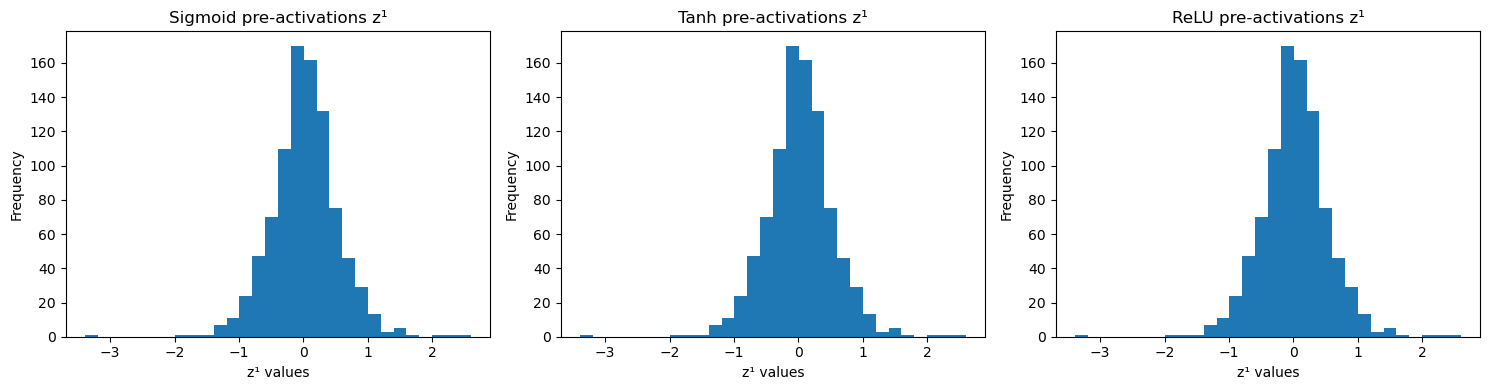

In [14]:
pre_activations = {
    "Sigmoid": sigmoid_z1.numpy().ravel(),
    "Tanh": tanh_z1.numpy().ravel(),
    "ReLU": relu_z1.numpy().ravel()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, values) in zip(axes, pre_activations.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name} pre-activations z¹")
    ax.set_xlabel("z¹ values")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

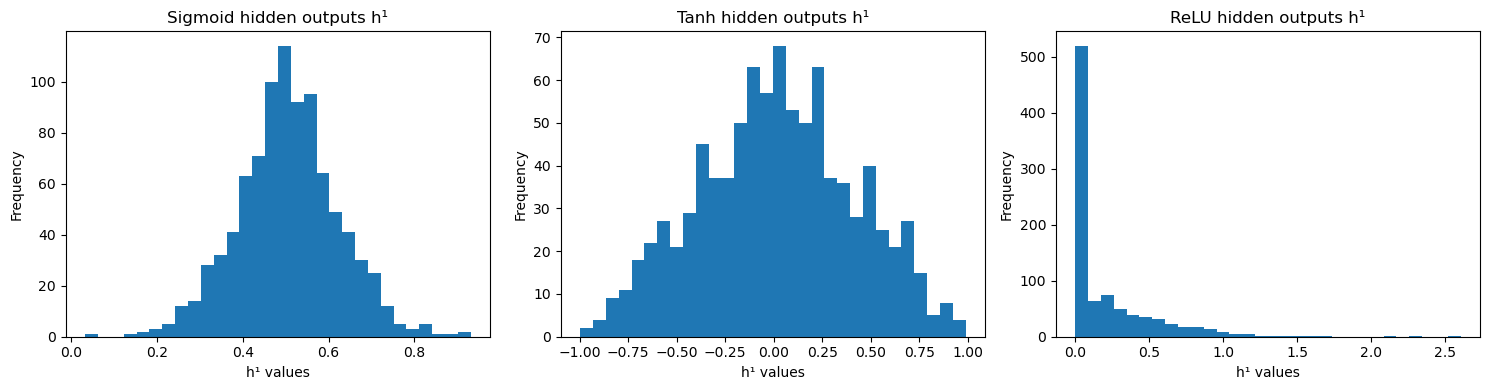

In [15]:
post_activations = {
    "Sigmoid": sigmoid_h1.numpy().ravel(),
    "Tanh": tanh_h1.numpy().ravel(),
    "ReLU": relu_h1.numpy().ravel()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, values) in zip(axes, post_activations.items()):
    ax.hist(values, bins=30)
    ax.set_title(f"{name} hidden outputs h¹")
    ax.set_xlabel("h¹ values")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [16]:
sigmoid_values = sigmoid_h1.numpy().ravel()
tanh_values = tanh_h1.numpy().ravel()
relu_values = relu_h1.numpy().ravel()

sigmoid_saturated = np.mean((sigmoid_values < 0.05) | (sigmoid_values > 0.95))

tanh_saturated = np.mean((tanh_values < -0.95) | (tanh_values > 0.95))

relu_inactive = np.mean(relu_values == 0)

print(f"Sigmoid saturated fraction: {sigmoid_saturated:.4f}")
print(f"Tanh saturated fraction: {tanh_saturated:.4f}")
print(f"ReLU inactive fraction: {relu_inactive:.4f}")

Sigmoid saturated fraction: 0.0011
Tanh saturated fraction: 0.0055
ReLU inactive fraction: 0.4825


For the sigmoid activation, the saturated fraction is the proportion of hidden outputs close to 0 or 1. For tanh, the saturated fraction is the proportion of hidden outputs close to -1 or 1. In my results, sigmoid and tanh may show some saturation, meaning their gradients can become very small in those regions.

For ReLU, the inactive fraction is the proportion of hidden outputs that are exactly 0. These are units where the pre-activation value was negative.

Based on the histograms, ReLU is often a better default for hidden layers because positive values keep a strong gradient and do not saturate like sigmoid or tanh. This helps deep networks learn faster and reduces the vanishing-gradient problem.